# Decision Tree Classification on Heart Disease Dataset
## With Visible Outputs

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_excel('/mnt/data/heart_disease(1).xlsx')

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (12, 2)


,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [2]:

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe(include='all'))


Column Names:
['age', 'Age in years']

Data Types:
age             object
Age in years    object
dtype: object

Missing Values:
age             0
Age in years    0
dtype: int64

Summary Statistics:


,age,Age in years
count,12,12
unique,12,12
top,Gender,"Gender ; Male - 1, Female -0"
freq,1,1


In [3]:

# Preprocessing

for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df.fillna(df.mean(numeric_only=True), inplace=True)

print("Preprocessed Dataset:")
display(df.head())


Preprocessed Dataset:


,age,Age in years
0,0,2
1,2,1
2,11,3
3,1,6
4,4,0


In [4]:

# Numeric Columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:")
print(num_cols.tolist())


Numeric Columns:
['age', 'Age in years']


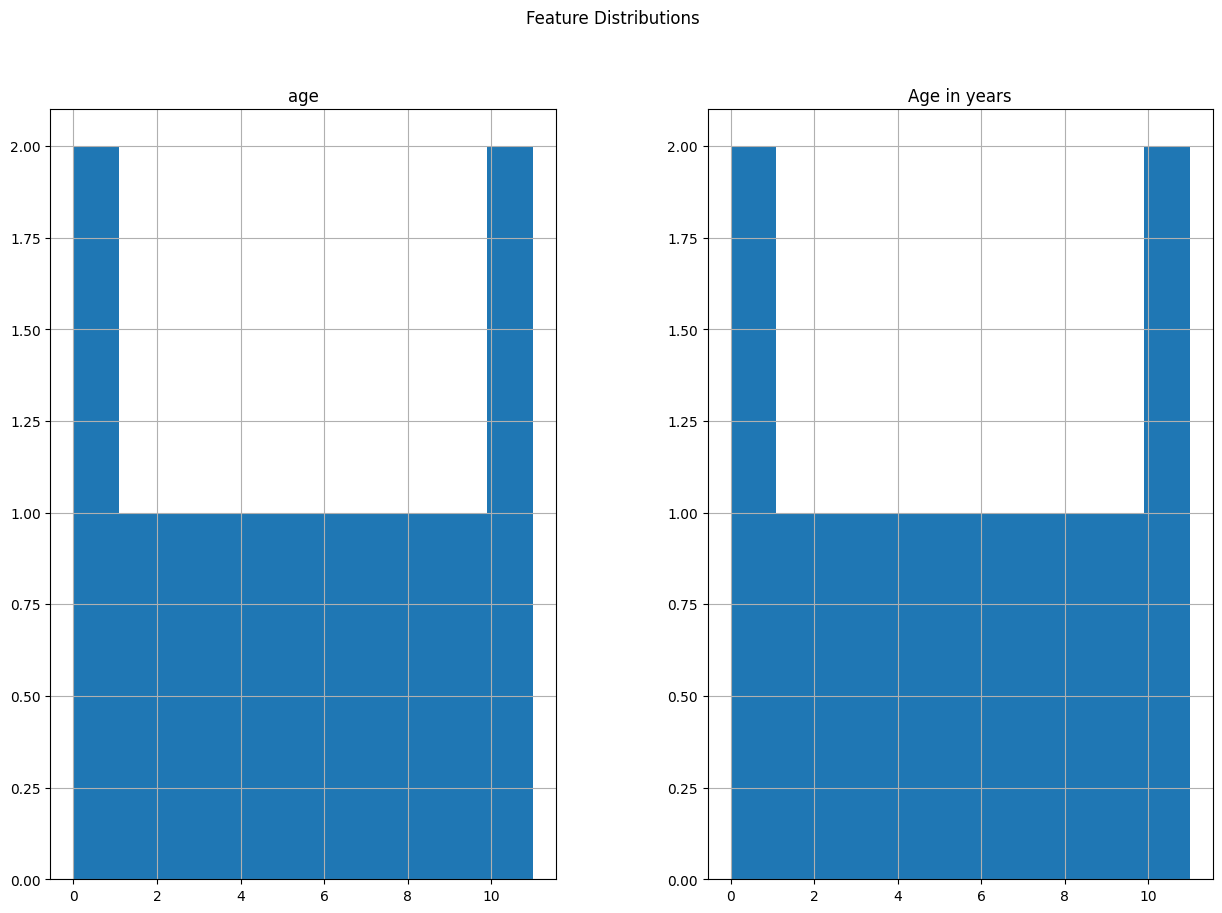

In [5]:

# Histograms

if len(num_cols) > 0:
    df[num_cols].hist(figsize=(15,10))
    plt.suptitle("Feature Distributions")
    plt.show()


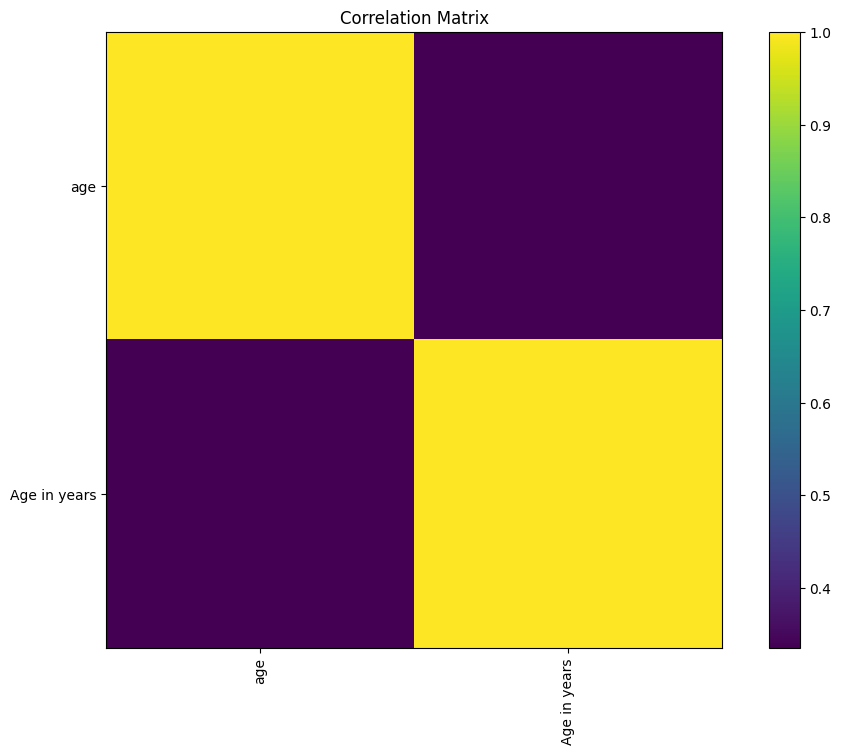

In [6]:

# Correlation Matrix

if len(num_cols) > 0:
    corr = df[num_cols].corr()

    plt.figure(figsize=(12,8))
    plt.imshow(corr, cmap='viridis')
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)

    plt.title("Correlation Matrix")
    plt.show()


In [7]:

# Feature and Target Split

target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (9, 1)
Testing Shape: (3, 1)


In [8]:

# Decision Tree Model

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy Score:
0.0

Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       1.0
           6       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           9       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


Confusion Matrix:
[[0 0 1 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 1 0 0]]


In [9]:

# Manual Hyperparameter Tuning

tuned_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

tuned_model.fit(X_train, y_train)

tuned_pred = tuned_model.predict(X_test)

print("Tuned Model Parameters:")
print(tuned_model.get_params())

print("\nTuned Model Accuracy:")
print(accuracy_score(y_test, tuned_pred))


Tuned Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Tuned Model Accuracy:
0.0


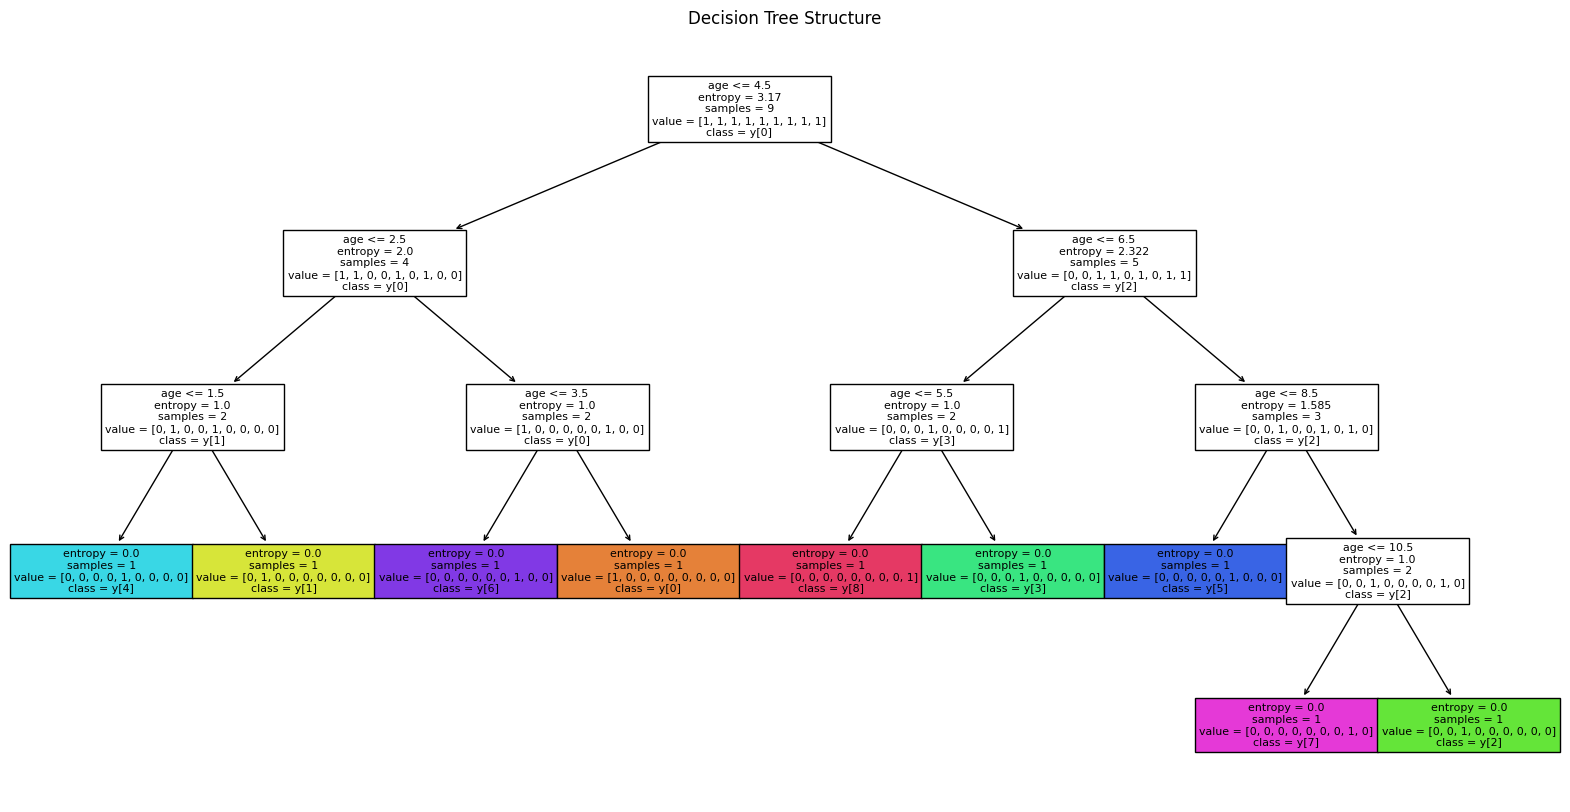

In [10]:

# Decision Tree Visualization

plt.figure(figsize=(20,10))

plot_tree(
    tuned_model,
    filled=True,
    feature_names=X.columns,
    class_names=True
)

plt.title("Decision Tree Structure")
plt.show()



# Interview Questions

## 1. Common Hyperparameters of Decision Trees
- max_depth controls maximum depth of the tree.
- min_samples_split defines minimum samples required for splitting.
- criterion measures split quality using gini or entropy.
- min_samples_leaf controls minimum samples at leaf nodes.

## 2. Difference Between Label Encoding and One-Hot Encoding
- Label Encoding converts categories into numbers.
- One-Hot Encoding creates separate binary columns.
- Label Encoding may create ordinal relationships.
- One-Hot Encoding avoids ordinal relationships but increases dimensions.


In [11]:

print("Decision Tree Assignment Completed Successfully!")


Decision Tree Assignment Completed Successfully!
